# Demo 7 - Detecção de Objetos do tipo Zero-shot

### Prof. Dr. Ahirton Lopes (https://github.com/ahirtonlopes)

In [13]:
! pip install transformers datasets


Tradicionalmente, os modelos usados ​​para [detecção de objetos](https://huggingface.co/docs/transformers/main/en/tasks/object_detection) exigem conjuntos de dados de imagens rotulados para treinamento,
e estão limitados a detectar o conjunto de classes dos dados de treinamento.

A detecção de objetos zero-shot é suportada pelo modelo [OWL-ViT](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/owlvit) que usa uma abordagem diferente. OWL-ViT
é um detector de objetos de vocabulário aberto. Isso significa que ele pode detectar objetos em imagens com base em consultas de texto livre sem
a necessidade de ajustar o modelo em conjuntos de dados rotulados.

OWL-ViT aproveita representações multimodais para realizar detecção de vocabulário aberto. Ele combina [CLIP](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/clip) com
cabeças leves de classificação e localização de objetos. A detecção de vocabulário aberto é obtida incorporando consultas de texto livre com o codificador de texto do CLIP e usando-as como entrada para os cabeçalhos de classificação e localização de objetos.
associa imagens e suas descrições textuais correspondentes, e o ViT processa patches de imagem como entradas.

Os autores
do OWL-ViT primeiro o treinaram num CLIP do zero e depois ajustou o OWL-ViT de ponta a ponta em conjuntos de dados de detecção de objetos padrão usando
uma perda de correspondência bipartida.

Com esta abordagem, o modelo pode detectar objetos com base em descrições textuais sem treinamento prévio em conjuntos de dados rotulados.

Neste guia, você aprenderá como usar o OWL-ViT:
- para detectar objetos com base em prompts de texto
- para detecção de objetos em lote
- para detecção de objetos guiada por imagem

Antes de começar, certifique-se de ter todas as bibliotecas necessárias instaladas:

```bash
pip instalar -q transformadores
```

## Pipeline

A maneira mais simples de testar inferência com OWL-ViT é usá-la em um [pipeline()](https://huggingface.co/docs/transformers/main/en/main_classes/pipelines#transformers.pipeline). Instanciar um pipeline
para detecção de objetos sem disparo a partir de um [ponto de verificação no Hugging Face Hub](https://huggingface.co/models?other=owlvit):

In [14]:
from transformers import pipeline

checkpoint = "google/owlvit-base-patch32"
detector = pipeline(model=checkpoint, task="zero-shot-object-detection")

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

OwlViTForObjectDetection LOAD REPORT from: google/owlvit-base-patch32
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
owlvit.vision_model.embeddings.position_ids | UNEXPECTED |  | 
owlvit.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Em seguida, escolha uma imagem na qual você gostaria de detectar objetos. Aqui usaremos a imagem da astronauta Eileen Collins que é
parte do conjunto de dados Great Images da [NASA](https://www.nasa.gov/multimedia/imagegallery/index.html).

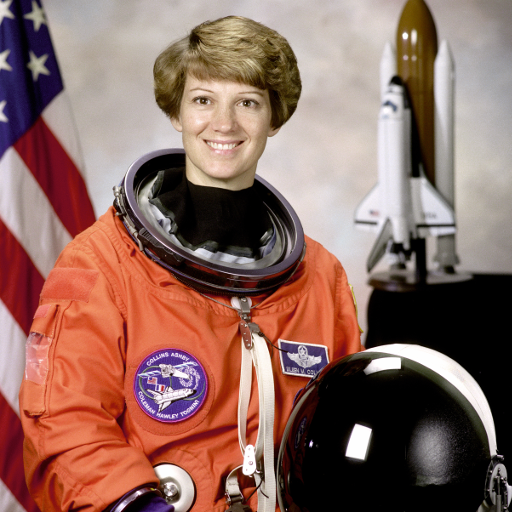

In [15]:
import skimage
import numpy as np
from PIL import Image

image = skimage.data.astronaut()
image = Image.fromarray(np.uint8(image)).convert("RGB")

image

<div class="flex justify-center">
     <img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/zero-sh-obj-detection_1.png" alt="Astronaut Eileen Collins"/>
</div>

Passe a imagem e os rótulos dos objetos candidatos a serem procurados para o pipeline. Aqui passamos a imagem diretamente; outras opções adequadas incluem um caminho local para uma imagem ou um URL de imagem. Também passamos descrições de texto para todos os itens que desejamos consultar na imagem.

In [16]:
predictions = detector(
    image,
    candidate_labels=["human face", "rocket", "nasa badge", "star-spangled banner"],
)
predictions

[{'score': 0.3570273816585541,
  'label': 'human face',
  'box': {'xmin': 180, 'ymin': 71, 'xmax': 271, 'ymax': 178}},
 {'score': 0.2807384729385376,
  'label': 'nasa badge',
  'box': {'xmin': 129, 'ymin': 348, 'xmax': 206, 'ymax': 427}},
 {'score': 0.21095183491706848,
  'label': 'rocket',
  'box': {'xmin': 350, 'ymin': -1, 'xmax': 468, 'ymax': 288}},
 {'score': 0.13779829442501068,
  'label': 'star-spangled banner',
  'box': {'xmin': 1, 'ymin': 1, 'xmax': 105, 'ymax': 509}},
 {'score': 0.11948907375335693,
  'label': 'nasa badge',
  'box': {'xmin': 277, 'ymin': 338, 'xmax': 327, 'ymax': 380}},
 {'score': 0.1065845713019371,
  'label': 'rocket',
  'box': {'xmin': 358, 'ymin': 64, 'xmax': 424, 'ymax': 280}}]

Visualizando as predições:

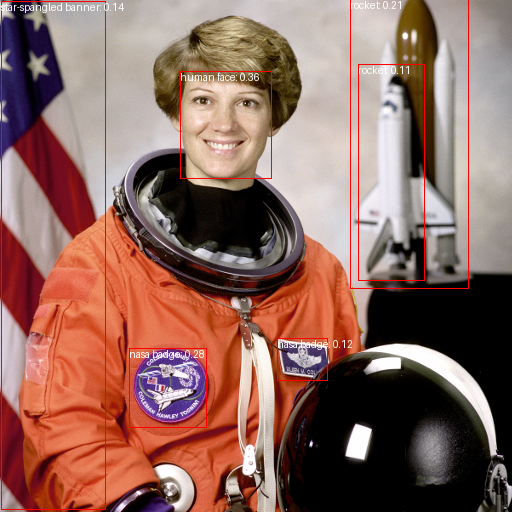

In [17]:
from PIL import ImageDraw

draw = ImageDraw.Draw(image)

for prediction in predictions:
    box = prediction["box"]
    label = prediction["label"]
    score = prediction["score"]

    xmin, ymin, xmax, ymax = box.values()
    draw.rectangle((xmin, ymin, xmax, ymax), outline="red", width=1)
    draw.text((xmin, ymin), f"{label}: {round(score,2)}", fill="white")

image

<div class="flex justify-center">
     <img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/zero-sh-obj-detection_2.png" alt="Visualized predictions on NASA image"/>
</div>

## Text-prompted zero-shot object detection (na mão)

In [18]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

model = AutoModelForZeroShotObjectDetection.from_pretrained(checkpoint)
processor = AutoProcessor.from_pretrained(checkpoint)

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

OwlViTForObjectDetection LOAD REPORT from: google/owlvit-base-patch32
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
owlvit.vision_model.embeddings.position_ids | UNEXPECTED |  | 
owlvit.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


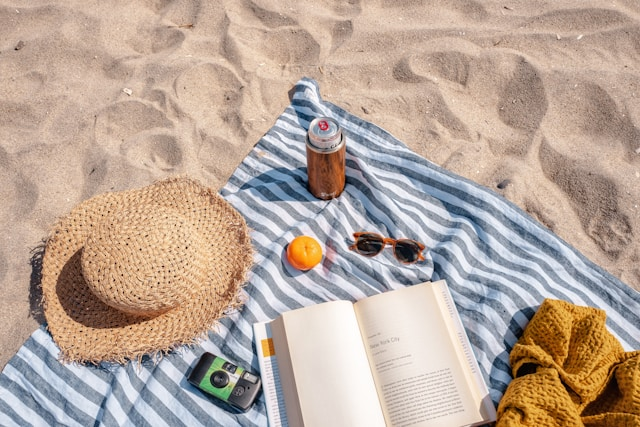

In [19]:
import requests

url = "https://unsplash.com/photos/oj0zeY2Ltk4/download?ixid=MnwxMjA3fDB8MXxzZWFyY2h8MTR8fHBpY25pY3xlbnwwfHx8fDE2Nzc0OTE1NDk&force=true&w=640"
im = Image.open(requests.get(url, stream=True).raw)
im

<div class="flex justify-center">
     <img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/zero-sh-obj-detection_3.png" alt="Beach photo"/>
</div>

Use o processador para preparar as entradas para o modelo. O processador combina um processador de imagem que prepara o
imagem para o modelo redimensionando-a e normalizando-a, e um [CLIPTokenizer](https://huggingface.co/docs/transformers/main/en/model_doc/clip#transformers.CLIPTokenizer) que cuida das entradas de texto.

In [20]:
text_queries = ["hat", "book", "sunglasses", "camera"]
inputs = processor(text=text_queries, images=im, return_tensors="pt")

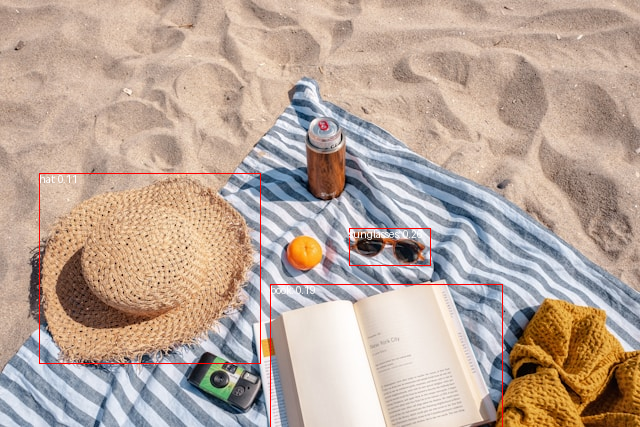

In [21]:
import torch
from PIL import ImageDraw

with torch.no_grad():
    outputs = model(**inputs)
    target_sizes = torch.tensor([im.size[::-1]])

    # Manual post-processing for single image (replacing processor.post_process_object_detection)
    threshold = 0.1 # Keep the original threshold

    logits = outputs.logits.squeeze(0) # Remove batch dimension for single image
    boxes = outputs.pred_boxes.squeeze(0) # Remove batch dimension for single image

    scores = torch.sigmoid(logits)
    max_scores, labels = scores.max(dim=-1) # Get the highest score and its corresponding label for each box

    keep = max_scores > threshold
    boxes = boxes[keep]
    max_scores = max_scores[keep]
    labels = labels[keep]

    # Rescale boxes from normalized (0-1) to original image dimensions
    img_h, img_w = target_sizes.squeeze(0)
    scale_fct = torch.tensor([img_w, img_h, img_w, img_h], device=boxes.device)
    boxes = boxes * scale_fct

    # Convert center_x, center_y, width, height to xmin, ymin, xmax, ymax
    boxes_xyxy = torch.cat([boxes[:, :2] - boxes[:, 2:] / 2, boxes[:, :2] + boxes[:, 2:] / 2], 1)

    # Format results
    results_list = []
    for score, label_idx, box in zip(max_scores, labels, boxes_xyxy):
        results_list.append({
            "score": score.item(),
            "label": label_idx.item(), # This is the index into text_queries
            "box": {
                "xmin": int(box[0].item()),
                "ymin": int(box[1].item()),
                "xmax": int(box[2].item()),
                "ymax": int(box[3].item()),
            },
        })
    results = results_list

draw = ImageDraw.Draw(im)

scores = [r["score"] for r in results] # Extract scores from the new results format
labels = [r["label"] for r in results] # Extract labels from the new results format
boxes = [r["box"] for r in results] # Extract boxes from the new results format

for box, score, label in zip(boxes, scores, labels):
    xmin, ymin, xmax, ymax = box.values()
    draw.rectangle((xmin, ymin, xmax, ymax), outline="red", width=1)
    draw.text((xmin, ymin), f"{text_queries[label]}: {round(score,2)}", fill="white")

im

<div class="flex justify-center">
     <img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/zero-sh-obj-detection_4.png" alt="Beach photo with detected objects"/>
</div>

## Batch processing

In [22]:
images = [image, im]
text_queries = [
    ["human face", "rocket", "nasa badge", "star-spangled banner"],
    ["hat", "book", "sunglasses", "camera"],
]
inputs = processor(text=text_queries, images=images, return_tensors="pt")

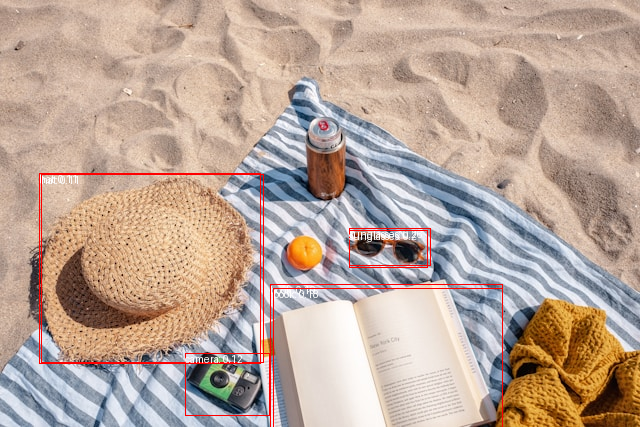

In [23]:
with torch.no_grad():
    outputs = model(**inputs)
    target_sizes = [x.size[::-1] for x in images]
    threshold = 0.1 # Keep the original threshold

    # Manual post-processing for batch (replacing processor.post_process_object_detection)
    batch_results = []
    for i in range(outputs.logits.shape[0]): # Iterate over images in the batch
        logits = outputs.logits[i] # (num_queries, num_labels)
        boxes = outputs.pred_boxes[i] # (num_queries, 4)
        img_h, img_w = target_sizes[i]

        scores = torch.sigmoid(logits)
        max_scores, labels = scores.max(dim=-1)

        keep = max_scores > threshold
        boxes = boxes[keep]
        max_scores = max_scores[keep]
        labels = labels[keep]

        scale_fct = torch.tensor([img_w, img_h, img_w, img_h], device=boxes.device)
        boxes = boxes * scale_fct

        boxes_xyxy = torch.cat([boxes[:, :2] - boxes[:, 2:] / 2, boxes[:, :2] + boxes[:, 2:] / 2], 1)

        image_results = []
        for score, label_idx, box in zip(max_scores, labels, boxes_xyxy):
            image_results.append({
                "score": score.item(),
                "label": label_idx.item(),
                "box": {
                    "xmin": int(box[0].item()),
                    "ymin": int(box[1].item()),
                    "xmax": int(box[2].item()),
                    "ymax": int(box[3].item()),
                },
            })
        batch_results.append(image_results)

    results = batch_results

image_idx = 1
draw = ImageDraw.Draw(images[image_idx])

scores = [r["score"] for r in results[image_idx]] # Extract scores from the new results format
labels = [r["label"] for r in results[image_idx]] # Extract labels from the new results format
boxes = [r["box"] for r in results[image_idx]] # Extract boxes from the new results format

for box, score, label in zip(boxes, scores, labels):
    xmin, ymin, xmax, ymax = box.values()
    draw.rectangle((xmin, ymin, xmax, ymax), outline="red", width=1)
    draw.text((xmin, ymin), f"{text_queries[image_idx][label]}: {round(score,2)}", fill="white")

images[image_idx]

<div class="flex justify-center">
     <img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/zero-sh-obj-detection_4.png" alt="Beach photo with detected objects"/>
</div>